<a href="https://colab.research.google.com/github/dai-fujiden/boite-a-jouets/blob/main/snow_simu/snow_flake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import matplotlib.animation as animation

In [12]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation  # [FIX] save_gif で使うのに import 漏れしていた
from scipy.spatial import cKDTree
from tqdm import tqdm


@dataclass
class ParticleState:
    time: float
    position: np.ndarray      # (dim, n_particle)
    frag: np.ndarray          # (n_particle,)  True = 吸着済み(固定), False = 拡散中(active)


class Particle:
    def __init__(
        self,
        nums=100,
        tmax=100,
        dt=1.0,   # [FIX] dt は移動量に反映されないため、1.0 にしないと無駄にステップ数が増えるだけ
        particle_init_posi_range=[
            [20, 40],
            [20, 40],
            [20, 40]
        ],
        boundary=[
            [0, 100],
            [0, 100],
            [0, 100]
        ]
    ):

        self.n_particle = nums
        self.dim = len(boundary)

        self.time = 0.0
        self.tmax = tmax
        self.dt = dt
        self.t = np.arange(0, tmax + dt, dt)

        self.boundary = [[int(b[0]), int(b[1])] for b in boundary]

        # ------------------------
        # 初期位置
        # ------------------------

        init_position = []

        for rng in particle_init_posi_range:
            init_position.append(
                np.random.randint(rng[0], rng[1], nums)
            )

        self.init_position = np.array(init_position)

        self.init_frag = np.zeros(nums, dtype=bool)

        # ------------------------
        # 時系列データ
        # ------------------------

        self.states = []

        for i, t in enumerate(tqdm(self.t, desc="Allocating states")):

            if i == 0:
                position = self.init_position.copy()
            else:
                position = np.zeros_like(self.init_position)

            self.states.append(
                ParticleState(
                    time=t,
                    position=position,
                    frag=self.init_frag.copy()
                )
            )

    def __repr__(self):
        return (
            f"Particle("
            f"n_particle={self.n_particle}, "
            f"dimension={self.dim}, "
            f"n_step={len(self.states)})"
        )

    def add_active_particles(self, added_position=None, added_time=0):
        """
        既存の粒子集団に、新たな粒子(典型的には最初から吸着済みの「核」)を追加する。

        [FIX] グローバル変数 particle.states を参照していたバグを self.states に修正。
        [NOTE] added_time は現状 self.states[0].time (=シミュレーション開始時刻) を
               想定しています。途中の時刻から粒子を追加する場合、それより前の
               ステップの position 配列サイズと self.n_particle が食い違い
               shape mismatch になるため、その場合は事前に警告します。
        """
        print(f"Old property "
              f"n_particle={self.n_particle}, "
              f"dimension={self.dim}, "
              f"n_step={len(self.states)}")
        print("-----------" * 6)

        added_position = np.array(added_position, dtype=float)
        added_nums = added_position.shape[1]

        if added_time > self.states[0].time:
            print(
                f"[WARNING] added_time={added_time} は開始時刻"
                f"{self.states[0].time} より後です。"
                f"added_time より前のステップは position の配列サイズが"
                f"self.n_particle と食い違うため、update() 実行時にエラーになる"
                f"可能性があります。added_time=0 での利用を推奨します。"
            )

        for state in self.states:  # [FIX] self.states を参照
            if state.time >= added_time:
                state.position = np.concatenate((state.position, added_position), axis=1)
                state.frag = np.concatenate((state.frag, np.ones(added_nums, dtype=bool)))

        self.n_particle = self.n_particle + added_nums
        print(f"Updated property "
              f"n_particle={self.n_particle}, "
              f"dimension={self.dim}, "
              f"n_step={len(self.states)}")

    def update_loop(self, step: int, dx_range: list = [-1, 1], dy_range: list = [-1, 1], fix_inactive=True):
        if step == 0:
            return

        state = self.states[step]
        _state = self.states[step - 1]

        # [FIX] 前ステップの吸着状態(frag)をこのステップに引き継ぐ。
        # これをしないと、各stepのfragが__init__/add_active_particles時点の
        # 初期状態のまま上書きされず、途中で吸着した粒子が
        # 次のstepでは「未吸着」に戻ってしまい、初期の核以外に吸着が広がらなかった。
        state.frag = _state.frag.copy()

        # 1. 移動量の生成
        dx = np.random.randint(dx_range[0], dx_range[1] + 1, self.n_particle)
        dy = np.random.randint(dy_range[0], dy_range[1] + 1, self.n_particle)

        # 2. 吸着済み(frag=True)粒子の移動を固定
        if fix_inactive:
            dx[_state.frag] = 0
            dy[_state.frag] = 0

        # 3. 位置の仮更新
        state.position[0] = _state.position[0] + dx
        if self.dim >= 2:
            state.position[1] = _state.position[1] + dy

        # (以下、境界処理は変更なし)
        xmin, xmax = self.boundary[0][0], self.boundary[0][1]

        under_x = state.position[0] < xmin
        if np.any(under_x):
            state.position[0][under_x] = 2 * xmin - state.position[0][under_x]

        over_x = state.position[0] > xmax
        if np.any(over_x):
            state.position[0][over_x] = 2 * xmax - state.position[0][over_x]

        if self.dim >= 2:
            ymin, ymax = self.boundary[1][0], self.boundary[1][1]

            under_y = state.position[1] < ymin
            if np.any(under_y):
                state.position[1][under_y] = 2 * ymin - state.position[1][under_y]

            over_y = state.position[1] > ymax
            if np.any(over_y):
                state.position[1][over_y] = 2 * ymax - state.position[1][over_y]

    def update(self, dx_range: list = [-1, 1], dy_range: list = [-1, 1], fix_inactive=True):
        """全ステップにわたってランダムウォークを適用する"""
        for i in tqdm(range(len(self.states)), desc="Updating Simulation"):
            self.update_loop(step=i, dx_range=dx_range, dy_range=dy_range, fix_inactive=fix_inactive)
            self.absorp_judge(step=i)

            # [FIX] active粒子がもう存在しない場合はここで終了(元の判定は常にTrueで機能していなかった)
            if not np.any(~self.states[i].frag):
                print(f"iter {i}: 全粒子が吸着済みのため終了します")
                break

    def absorp_judge(self, step):
        """
        active粒子が inactive(吸着済み)粒子と上下左右(4近傍)で隣接したら吸着する。

        [FIX] チェビシェフ距離(p=inf)だと斜め方向(dx=1,dy=1)も距離1と
        判定されて吸着してしまうため、マンハッタン距離(p=1)に変更。
        マンハッタン距離<=1 は (dx,dy) が (0,0),(1,0),(-1,0),(0,1),(0,-1) の
        場合のみ成立し、斜め(1,1)は距離2になるため自動的に除外される。
        """
        state = self.states[step]
        active = ~state.frag
        inactive = state.frag

        if not np.any(inactive) or not np.any(active):
            return

        active_pos = state.position[:, active].T      # (n_active, dim)
        inactive_pos = state.position[:, inactive].T   # (n_inactive, dim)

        tree = cKDTree(inactive_pos)
        # p=1 -> マンハッタン距離での最近傍距離（4近傍判定）
        dist, _ = tree.query(active_pos, k=1, p=1)

        absorbed = dist <= 1

        state.frag[active] = absorbed

    def get_state(self, step):
        return self.states[step]

    def plot(
        self,
        step=0,
        figsize=(3, 3),
        dpi=150,
        particle_size=1,
        save_path=None,
    ):

        state = self.states[step]

        if self.dim == 2:

            fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

            ax.set_xlim(self.boundary[0])
            ax.set_ylim(self.boundary[1])

            active = ~state.frag
            inactive = state.frag

            # [FIX] ラベルが active/inactive で逆になっていたのを修正
            ax.scatter(
                state.position[0][active],
                state.position[1][active],
                s=particle_size,
                facecolors="#f58a8a",          # blue
                edgecolors="#b41f1f",          # blue
                alpha=0.8,

                lw=0.5,
                label="Active",
                zorder=2,
            )

            ax.scatter(
                state.position[0][inactive],
                state.position[1][inactive],
                s=particle_size,
                facecolors="#14d8f1",          # red
                edgecolors="#3877ec",
                alpha=0.9,
                marker="s",
                lw=0.5,
                label="Absorbed",
                zorder=3,
            )

            ax.set_xlabel("x")
            ax.set_ylabel("y")
            ax.set_title(f"$t={state.time:.2f}$")
            ax.set_aspect("equal")
            ax.tick_params(direction="in")
            ax.legend(frameon=False)
            ax.grid(False)

            fig.tight_layout()

            if save_path is not None:
                fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

            plt.show()
            return fig, ax
    def save_gif(self, filename="simulation.gif", fps=20, figsize=(4, 4), dpi=80,
                particle_size=8, frame_step=5):  # [FIX] frame_stepのデフォルトを上げてフレーム数を削減
        if self.dim != 2:
            raise ValueError("GIF creation is only supported for 2D simulations.")

        frame_indices = list(range(0, len(self.states), frame_step))
        print(f"Total steps: {len(self.states)}, rendering {len(frame_indices)} frames")


        state0 = self.states[0]
        fig, ax = self.plot(step=0, figsize=figsize, dpi=dpi, particle_size=particle_size)
        ax.set_xlim(self.boundary[0])
        ax.set_ylim(self.boundary[1])
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_aspect("equal")
        ax.tick_params(direction="in")

        active0 = ~state0.frag
        absorbed0 = state0.frag

        # [FIX] edgecolors を無くして描画負荷を軽減
        scat_active = ax.scatter(
            state0.position[0][active0], state0.position[1][active0],
            s=particle_size, c="#1f77b4", alpha=0.8, label="Active"
        )
        scat_absorbed = ax.scatter(
            state0.position[0][absorbed0], state0.position[1][absorbed0],
            s=particle_size, c="#d62728", alpha=0.9, label="Absorbed"
        )
        title = ax.set_title(f"$t={state0.time:.2f}$")
        ax.legend(frameon=False, loc="upper right")


        def update_frame(idx):
            state = self.states[idx]
            # [FIX] 元コードは初期フレームの frag(is_absorbed)を使い回しており、
            # 成長がアニメーションに反映されなかった。毎フレーム state.frag を使うよう修正。
            active = ~state.frag
            absorbed = state.frag

            scat_active.set_offsets(np.c_[state.position[0][active], state.position[1][active]])
            scat_absorbed.set_offsets(np.c_[state.position[0][absorbed], state.position[1][absorbed]])
            title.set_text(f"$t={state.time:.2f}$")
            return scat_active, scat_absorbed, title

        ani = animation.FuncAnimation(
            fig, update_frame, frames=frame_indices, interval=1000 / fps, blit=True
        )

        print(f"Saving GIF to {filename}...")
        ani.save(filename, writer="pillow", fps=fps)
        plt.close(fig)
        print("GIF save completed!")

    def make_dataframe(self, step=0):
        """指定したステップの状態をpandas.DataFrameに変換する"""
        state = self.states[step]

        # positionは (dim, n_particle) なので転置して (n_particle, dim) にする
        posi = state.position.T

        # 次元数に応じた列名を作成 (例: 2次元なら ["x", "y"], 3次元なら ["x", "y", "z"])
        columns = ["x", "y", "z"][:self.dim]

        # pandas DataFrameを作成
        df = pd.DataFrame(posi, columns=columns)

        # 吸着状態フラグを追加
        df["is_absorbed"] = state.frag

        return df


In [13]:
particle = Particle(nums = 1_000, tmax = 20_000,boundary = [[0, 200], [0, 200]], particle_init_posi_range=[[40, 160], [40, 160]])

Allocating states: 100%|██████████| 20001/20001 [00:00<00:00, 90253.70it/s] 


In [14]:
particle.make_dataframe(step = 1)

,x,y,is_absorbed
0,0,0,False
1,0,0,False
2,0,0,False
3,0,0,False
4,0,0,False
...,...,...,...
995,0,0,False
996,0,0,False
997,0,0,False
998,0,0,False


In [15]:
thetas = np.linspace(0, 2 * np.pi, 100)
x_active = 100 + 1 * np.cos(thetas)
y_active = 100 + 1 * np.sin(thetas)
position_active = np.array([x_active, y_active])

particle.add_active_particles(added_position=position_active, added_time=0)

Old property n_particle=1000, dimension=2, n_step=20001
------------------------------------------------------------------
Updated property n_particle=1100, dimension=2, n_step=20001


In [16]:
particle.update(fix_inactive= True)


Updating Simulation: 100%|██████████| 20001/20001 [00:18<00:00, 1075.87it/s]


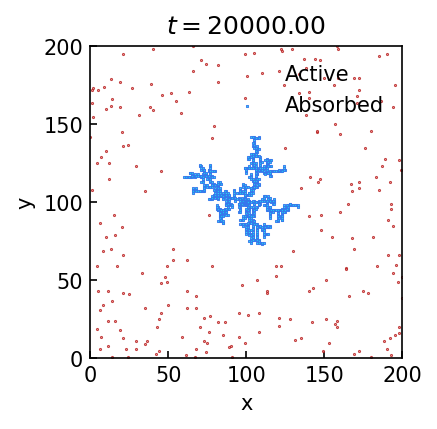

(<Figure size 450x450 with 1 Axes>,
 <Axes: title={'center': '$t=20000.00$'}, xlabel='x', ylabel='y'>)

In [17]:
particle.plot(step =20000, particle_size= 1)

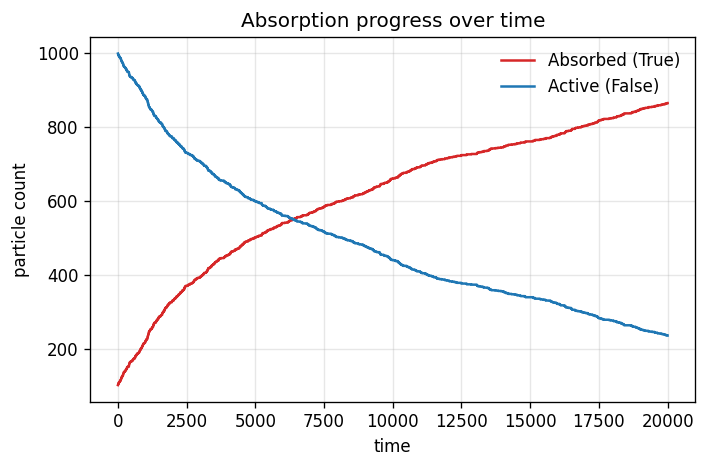

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 各ステップの frag 配列を集める
frag_history = np.array([state.frag for state in particle.states])  # shape: (n_steps, n_particle)

# ステップごとの吸着済み数・active数を数え上げ
n_absorbed = frag_history.sum(axis=1)          # True の数
n_active = (~frag_history).sum(axis=1)         # False の数

times = np.array([state.time for state in particle.states])

# ---- プロット ----
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

ax.plot(times, n_absorbed, label="Absorbed (True)", color="#d62728")
ax.plot(times, n_active, label="Active (False)", color="#1f77b4")

ax.set_xlabel("time")
ax.set_ylabel("particle count")
ax.set_title("Absorption progress over time")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

(865, 3)


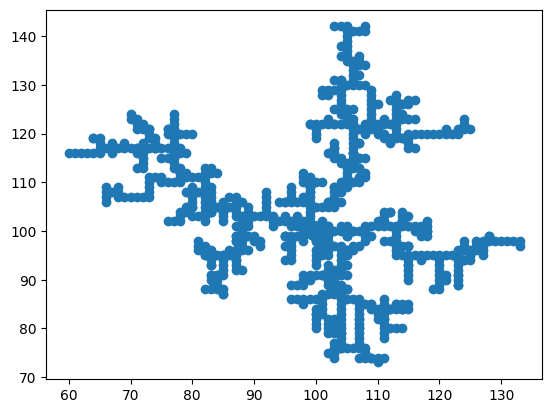

In [19]:
df = particle.make_dataframe(step=20000)
df_true = df[df["is_absorbed"] ]
print(df_true.shape)

plt.scatter(df_true["x"], df_true["y"])

Total steps: 20001, rendering 4001 frames


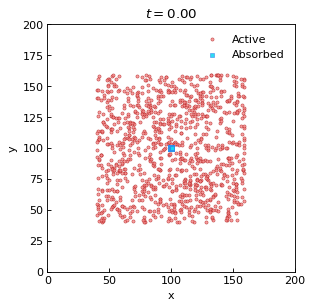

Saving GIF to simulation.gif...
GIF save completed!


In [20]:
particle.save_gif()